In [25]:
import tensorflow as tf

# Check for GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"GPU found and available: {gpu_devices}")
    print("TensorFlow will use the GPU for training.")
else:
    print("No GPU found. Please go to 'Runtime' -> 'Change runtime type' and select 'T4 GPU'.")

GPU found and available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow will use the GPU for training.


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import tensorflow as tf
import os
import shutil

base_data_dir = "/content/drive/MyDrive/Colab Notebooks/Licenta/lfw"
filtered_data_dir = "/content/lfw_filtered"

# Create a filtered directory if it doesn't exist
if os.path.exists(filtered_data_dir):
    shutil.rmtree(filtered_data_dir)
os.makedirs(filtered_data_dir)

# Filter classes with at least 50 images
min_images = 50
valid_classes = []

for person in os.listdir(base_data_dir):
    person_path = os.path.join(base_data_dir, person)
    if os.path.isdir(person_path):
        if len(os.listdir(person_path)) >= min_images:
            valid_classes.append(person)
            # Symlink or copy to the local filtered directory for faster access
            shutil.copytree(person_path, os.path.join(filtered_data_dir, person))

print(f"Filtered dataset to {len(valid_classes)} classes with at least {min_images} images.")

# Split into training (80%) and validation (20%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    filtered_data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    filtered_data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
batch_size = 32

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

Filtered dataset to 14 classes with at least 50 images.
Found 1660 files belonging to 14 classes.
Using 1328 files for training.
Found 1660 files belonging to 14 classes.
Using 332 files for validation.
Number of training batches: 42
Number of validation batches: 11


Total classes: 14
Top 10 classes by image count:
  George_W_Bush: 530
  Colin_Powell: 236
  Tony_Blair: 144
  Donald_Rumsfeld: 121
  Gerhard_Schroeder: 109
  Ariel_Sharon: 77
  Hugo_Chavez: 71
  Junichiro_Koizumi: 60
  Jean_Chretien: 55
  John_Ashcroft: 53


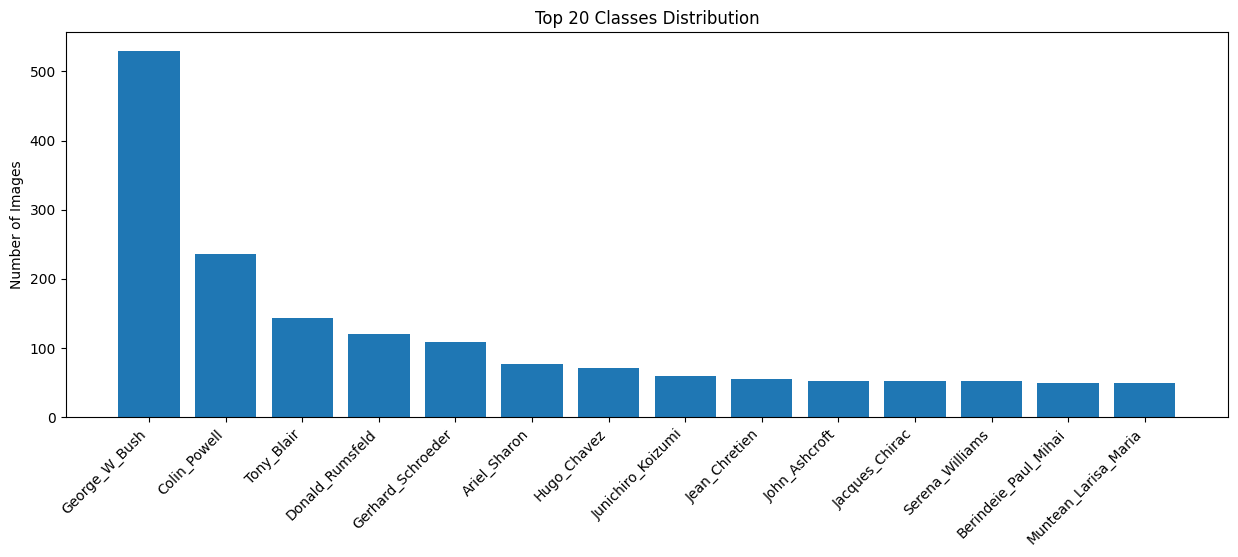

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Check class distribution
class_counts = {}
for label in os.listdir(filtered_data_dir):
    label_path = os.path.join(filtered_data_dir, label)
    if os.path.isdir(label_path):
        class_counts[label] = len(os.listdir(label_path))

sorted_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))

print(f"Total classes: {len(sorted_counts)}")
print("Top 10 classes by image count:")
for name, count in list(sorted_counts.items())[:10]:
    print(f"  {name}: {count}")

# Visualize class distribution
plt.figure(figsize=(15, 5))
plt.bar(list(sorted_counts.keys())[:20], list(sorted_counts.values())[:20])
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Classes Distribution')
plt.ylabel('Number of Images')
plt.show()

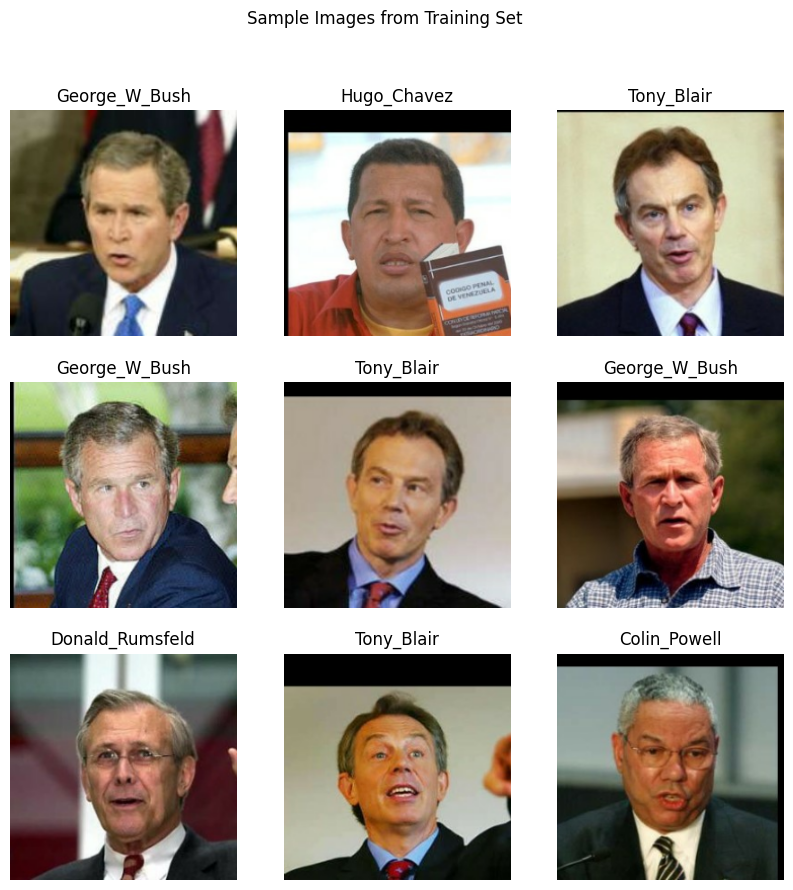

In [29]:
# Visualize sample images from the dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Sample Images from Training Set")
plt.show()

In [30]:
import tensorflow as tf
from tensorflow.keras import layers

# Standard normalization mapping using the new datasets
normalization_layer = layers.Rescaling(1./255)

train_ds_final = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_ds_final = val_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(tf.data.AUTOTUNE)

print(f"Data pipeline updated for {len(class_names)} classes.")

Data pipeline updated for 14 classes.


In [31]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_dir = "/content/drive/MyDrive/Colab Notebooks/Licenta/ResNet50_lfw/Checkpoints"
model_name = "PersonCNN_ResNet50"

if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)
    print(f"Created directory: {checkpoint_dir}")

# To safely use val_accuracy in the filename, we must save at the end of an epoch.
# We'll use save_freq='epoch' and a custom Callback to save every 2 epochs.
class CustomModelCheckpoint(ModelCheckpoint):
    def on_epoch_end(self, epoch, logs=None):
        # Epoch is 0-indexed, so (epoch + 1) % 2 == 0 saves at 2, 4, 6...
        if (epoch + 1) % 2 == 0:
            super().on_epoch_end(epoch, logs)

checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_epoch_{{epoch:02d}}_val_acc_{{val_accuracy:.4f}}.keras")

# save_weights_only=False ensures the whole model is saved for other devices
checkpoint_callback = CustomModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_freq='epoch'
)

print("Fixed callback: Now saving the full model every 2 epochs at epoch end.")

Fixed callback: Now saving the full model every 2 epochs at epoch end.


## Build the ResNet50 Model

We'll use a pre-trained ResNet50 model from `tf.keras.applications` and add a custom classification head on top.

In [32]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Rebuilding the model for 12 classes
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning: Unfreeze the top layers of the base model
base_model.trainable = True
# Freeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Use a smaller learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(f"Model re-initialized for 12 classes with fine-tuning enabled (last 20 layers unfrozen).")

Model re-initialized for 12 classes with fine-tuning enabled (last 20 layers unfrozen).


## Train the Model

Now, let's train the model using the prepared training and validation datasets.

## Retrain the Model with Preprocessed Data

Now, let's retrain the model using the augmented training dataset and the normalized validation dataset. We will use the same model architecture as before, but with the benefit of improved data.

In [33]:
epochs = 60

# Retraining with fine-tuning and smaller learning rate
history = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=epochs,
    callbacks=[checkpoint_callback]
)

print('Retraining with fine-tuning initiated.')

Epoch 1/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 455ms/step - accuracy: 0.3133 - loss: 2.3018 - val_accuracy: 0.2861 - val_loss: 2.4834
Epoch 2/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.3584 - loss: 2.0368 - val_accuracy: 0.2560 - val_loss: 2.4986
Epoch 3/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.4202 - loss: 1.8463 - val_accuracy: 0.0452 - val_loss: 2.5400
Epoch 4/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 230ms/step - accuracy: 0.4721 - loss: 1.6851 - val_accuracy: 0.0452 - val_loss: 2.5484
Epoch 5/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - accuracy: 0.5301 - loss: 1.5260 - val_accuracy: 0.0452 - val_loss: 2.5271
Epoch 6/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 237ms/step - accuracy: 0.5896 - loss: 1.3875 - val_accuracy: 0.0934 - val_loss: 2.4785
Epoch 7/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 158ms/step - accuracy: 0.6340 - loss: 1.2554 - val_accuracy: 0.2048 - val_loss: 2.4291
Epoch 8/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 225ms/step - accuracy: 0.6935 - loss: 1.1265 - val_accuracy

## Evaluate the Model

After training, let's evaluate the model's performance on the unseen test dataset.

### Training and Validation Accuracy

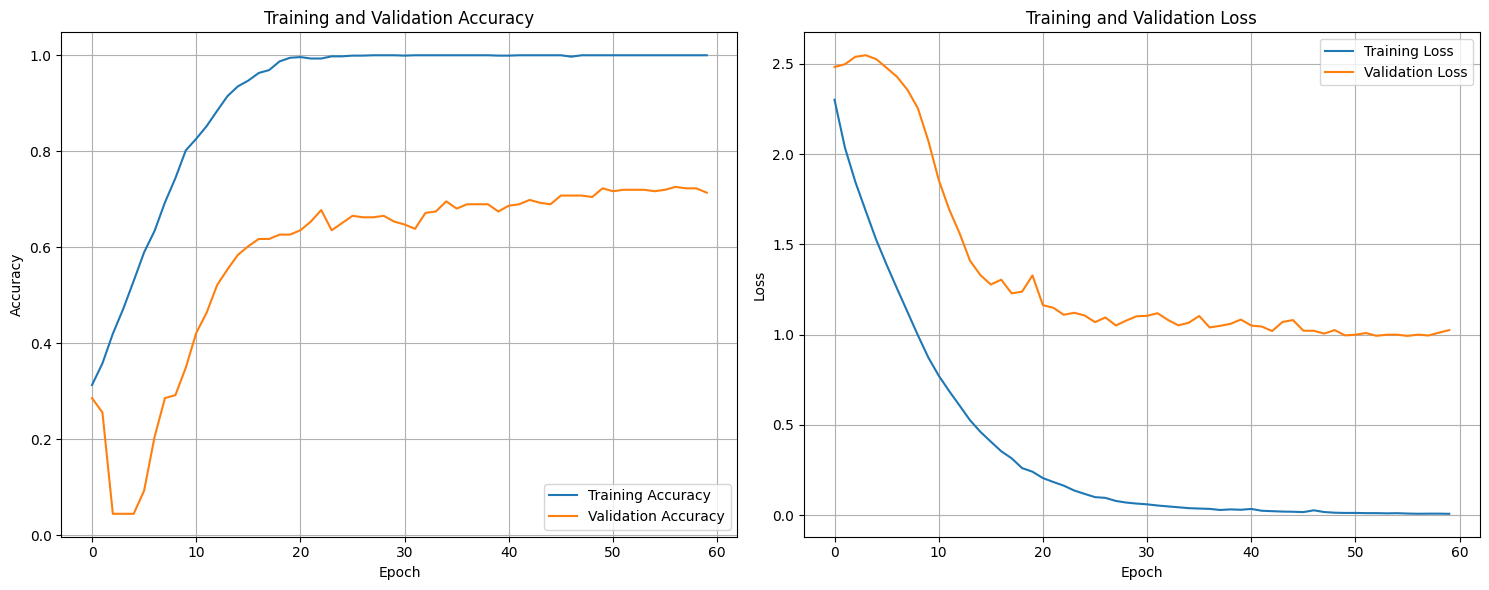

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Subplot for Training and Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Subplot for Training and Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Calculate and Plot Precision, Confusion Matrix, and Per-Class Metrics

To calculate precision and generate a confusion matrix, we need to get predictions from our model on the validation dataset.

In [39]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predicted labels for the validation set
val_labels = []
val_predictions = []

for images, labels in val_ds_final:
    val_labels.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    val_predictions.extend(np.argmax(preds, axis=1))

val_labels = np.array(val_labels)
val_predictions = np.array(val_predictions)

print("Predictions generated for validation set.")

Predictions generated for validation set.


### Confusion Matrix

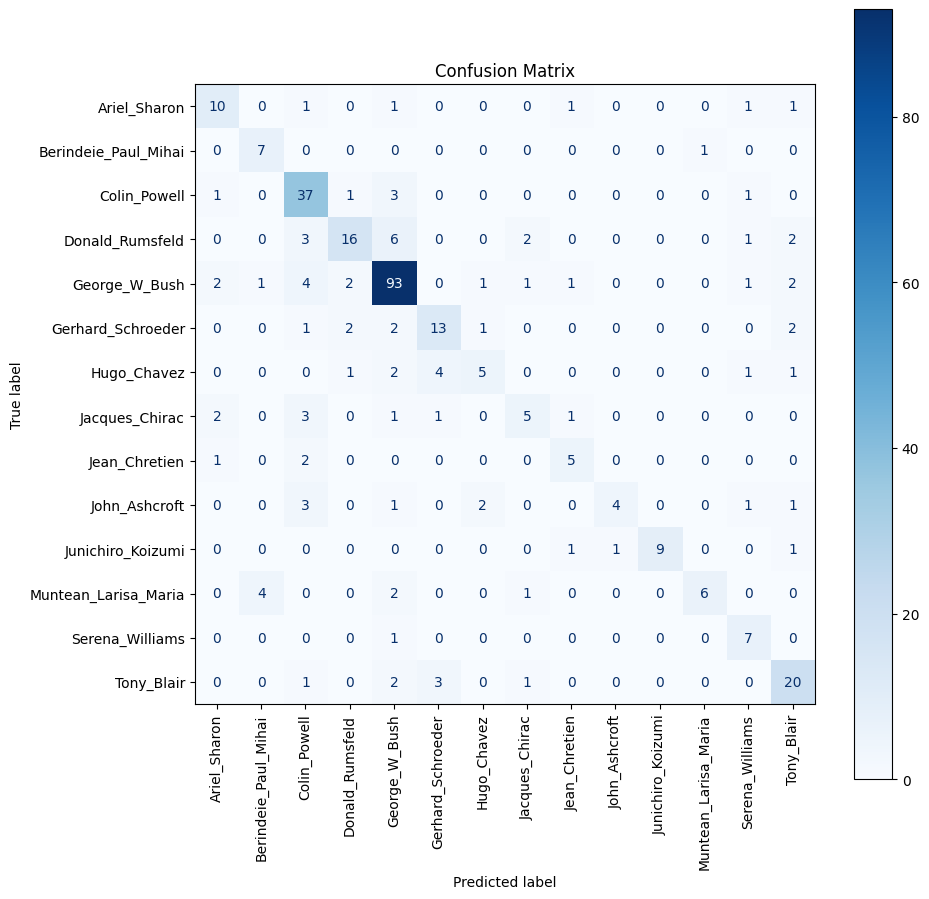

In [40]:
cm = confusion_matrix(val_labels, val_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

### Classification Report (Precision, Recall, F1-Score per class)

In [37]:
report = classification_report(val_labels, val_predictions, target_names=class_names)
print(report)

                      precision    recall  f1-score   support

        Ariel_Sharon       0.62      0.67      0.65        15
Berindeie_Paul_Mihai       0.58      0.88      0.70         8
        Colin_Powell       0.67      0.86      0.76        43
     Donald_Rumsfeld       0.73      0.53      0.62        30
       George_W_Bush       0.82      0.86      0.84       108
   Gerhard_Schroeder       0.62      0.62      0.62        21
         Hugo_Chavez       0.56      0.36      0.43        14
      Jacques_Chirac       0.50      0.38      0.43        13
       Jean_Chretien       0.56      0.62      0.59         8
       John_Ashcroft       0.80      0.33      0.47        12
   Junichiro_Koizumi       1.00      0.75      0.86        12
Muntean_Larisa_Maria       0.86      0.46      0.60        13
     Serena_Williams       0.54      0.88      0.67         8
          Tony_Blair       0.67      0.74      0.70        27

            accuracy                           0.71       332
      